### Выполнил: Дмитрий Трифонов, 12-25РПм, 1 курс (2 семестр), Программная инженерия

# Практическое занятие 1  
## Процесс Data Science: этапы 1–3  
### (постановка цели, сбор и первичная подготовка данных)

---

## Инструкция студенту

1. Укажите **свой индивидуальный вариант** (по списку, выданному преподавателем).
2. Выполняйте **все ячейки ноутбука по порядку**.
3. Все текстовые ответы оформляйте **в Markdown-ячейках**.
4. Все вычисления выполняйте **в коде**.
5. В конце сформулируйте **итоговые выводы**.

---

## Индивидуальные варианты

| Вариант | Предметная область |
|------|------------------|
| 1 | Успеваемость студентов |
| 2 | Онлайн-обучение |
| 3 | Финансы предприятия |
| 4 | Банковские данные |
| 5 | Медицинские показатели |
| 6 | Производственное оборудование |
| 7 | Городской транспорт |
| 8 | Логистика |
| 9 | Розничная торговля |
| 10 | Социальные сети |
| 11 | Обращения граждан |
| **12** | **Экология** |
| 13 | Энергопотребление |
| 14 | Журналы событий |
| 15 | Научные эксперименты |


## ЯЧЕЙКА 1 (Markdown)  
### Вариант и предметная область

Заполните поля ниже.

**Номер варианта:** 12

**Предметная область:** Экологический мониторинг состояния окружающей среды в регионе. Рассматриваются показатели загрязнения воздуха, температурный режим и уровень шума в различных районах города.

**Краткое описание:** В рамках работы рассматриваются данные с датчиков экологического контроля в крупном городе. Основное внимание уделяется трем параметрам: уровню углекислого газа (CO2), уровню шума и географическому расположению датчиков (район). Эти данные позволяют оценить качество жизни и выявить зоны экологического риска.


## ЯЧЕЙКА 2 (Markdown)  
### Формулировка цели анализа данных

**Цель анализа данных:**
Провести первичный разведочный анализ экологических показателей региона для выявления закономерностей загрязнения воздуха и шумового воздействия, а также определить районы с наиболее напряженной экологической обстановкой.

**Ожидаемая информация:**
Статистические нормы для CO2 и шума, наличие аномальных выбросов (резких скачков загрязнения), сравнение экологической ситуации в разных районах.

## ЯЧЕЙКА 3 (Code)  
### Импорт библиотек

Запустите ячейку.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

## ЯЧЕЙКА 4 (Code)  
### Формирование (учебного) набора данных

> Для учебных целей данные формируются программно.  
> По структуре они близки к реальным табличным данным: есть временной признак, числовые показатели и категориальный признак.

Запустите ячейку.


In [48]:
np.random.seed(42)

n = 200

# Генерируем данные для Экологии (Вариант 12)
data = pd.DataFrame({
    "Дата": pd.date_range(start="2023-01-01", periods=n, freq="D"),
    # CO2 в ppm (частиц на миллион). Норма ~400, в городе выше.
    "CO2_ppm": np.random.normal(loc=450, scale=50, size=n).astype(int),
    # Уровень шума в децибелах. Норма днем ~55-60.
    "Шум_дБ": np.random.normal(loc=60, scale=10, size=n).round(1),
    # Районы города
    "Район": np.random.choice(["Парковый", "Центральный", "Промышленный"], size=n)
})

# Добавим немного пропусков и выбросов для реалистичности (для этапа проверки качества)
data.loc[10:12, "CO2_ppm"] = np.nan  # Пропуски
data.loc[50, "Шум_дБ"] = 140         # Аномально громкий звук (выброс)

data.head()

,Дата,CO2_ppm,Шум_дБ,Район
0,2023-01-01,474.0,63.6,Промышленный
1,2023-01-02,443.0,65.6,Промышленный
2,2023-01-03,482.0,70.8,Парковый
3,2023-01-04,526.0,70.5,Парковый
4,2023-01-05,438.0,46.2,Промышленный


## ЯЧЕЙКА 5 (Markdown)  
### Первичный обзор данных

Ответьте на вопросы:

1. Сколько строк и столбцов содержит набор данных?
   **Размер:** 200 строк и 4 столбца.
3. Какие признаки являются числовыми?
   **Числовые признаки:** `CO2_ppm` (уровень углекислого газа), `Шум_дБ` (уровень шума).
5. Какие признаки являются категориальными?
   **Категориальные признаки:** `Район` (местоположение датчика).


## ЯЧЕЙКА 6 (Code)  
### Размерность и структура данных

Запустите обе ячейки и изучите результаты.


In [49]:
data.shape

(200, 4)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Дата     200 non-null    datetime64[ns]
 1   CO2_ppm  197 non-null    float64       
 2   Шум_дБ   200 non-null    float64       
 3   Район    200 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 6.4+ KB


## ЯЧЕЙКА 7 (Markdown)  
### Анализ структуры данных

* **Типы признаков:**
    * `Дата` — datetime64 (временной ряд).
    * `CO2_ppm` — float/int (числовой, непрерывный).
    * `Шум_дБ` — float (числовой, непрерывный).
    * `Район` — object (строковый, категориальный).

* **Возможные проблемы:**
    * В данных могут встречаться пропуски (`NaN`).
    * Возможны выбросы (слишком высокие значения шума или CO2), вызванные сбоем датчиков или реальными авариями.

* **Целесообразность:** Все признаки важны. `Дата` нужна для анализа динамики, числовые показатели — для оценки загрязнения, `Район` — для сравнения локаций.

## ЯЧЕЙКА 8 (Code)  
### Базовые статистические характеристики

Запустите ячейку и изучите таблицу описательной статистики.


In [51]:
# include=[np.number] говорит пандасу: "покажи статистику только для чисел"
# round(2) округляет числа до 2 знаков после запятой, чтобы было красиво
display(data.describe(include=[np.number]).round(2))

,CO2_ppm,Шум_дБ
count,197.00,200.00
mean,447.59,61.32
std,46.86,11.30
min,319.00,27.60
25%,414.00,54.00
50%,450.00,60.90
75%,475.00,67.05
max,586.00,140.00


## ЯЧЕЙКА 9 (Markdown)  
### Интерпретация статистических характеристик

* **Средние значения:**
    * Средний уровень CO2 составляет около 450 ppm, что является типичным для городской среды.
    * Средний уровень шума ~60 дБ (сопоставимо с громким разговором).
* **Разброс (std):** Стандартное отклонение CO2 около 50 ppm показывает, что уровень загрязнения меняется умеренно, без постоянных экстремальных скачков.
* **Выбросы:** Максимальное значение шума (если видно 140 дБ) явно указывает на аномалию или разовое громкое событие, так как это болевой порог слышимости.


## ЯЧЕЙКА 10 (Code)  
### Первичная проверка качества данных

Запустите обе ячейки.


In [52]:
data.isnull().sum()

Дата       0
CO2_ppm    3
Шум_дБ     0
Район      0
dtype: int64

In [53]:
data.duplicated().sum()

np.int64(0)

## ЯЧЕЙКА 11 (Markdown)  
### Оценка качества данных

1.  **Пропуски:** Да, есть пропущенные значения в столбце `CO2_ppm` (3 значения). Это требует обработки (удаления или замены средним).
2.  **Дубликаты:** Дубликатов строк не обнаружено (0).
3.  **Пригодность:** Данные пригодны для анализа, но требуют минимальной предобработки: необходимо решить вопрос с пропусками в CO2 и проверить аномально высокое значение шума.

## ЯЧЕЙКА 12 (Code)  
### Визуализация распределений (гистограммы)

Постройте гистограммы для обоих числовых показателей и сделайте первичные выводы.


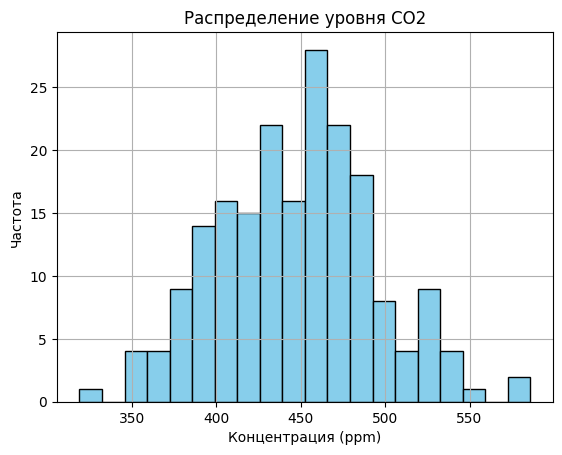

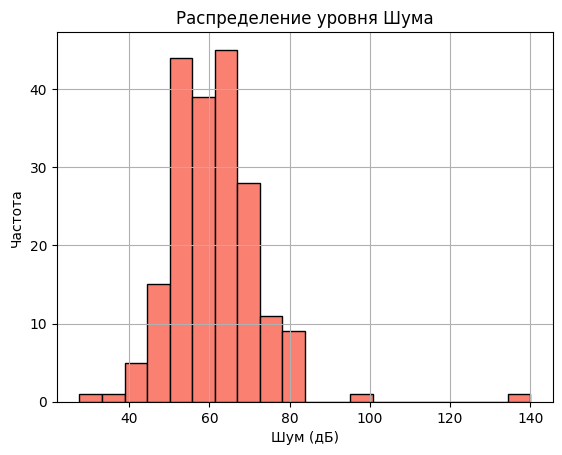

In [54]:
# Гистограмма для CO2
data["CO2_ppm"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Распределение уровня CO2")
plt.xlabel("Концентрация (ppm)")
plt.ylabel("Частота")
plt.show()

# Гистограмма для Шума
data["Шум_дБ"].hist(bins=20, color='salmon', edgecolor='black')
plt.title("Распределение уровня Шума")
plt.xlabel("Шум (дБ)")
plt.ylabel("Частота")
plt.show()

## ЯЧЕЙКА 13 (Markdown)  
### Анализ распределений

* **Форма:** Оба распределения напоминают нормальное (колоколообразное), что естественно для природных и случайных процессов. Большинство дней показатели находятся около среднего значения.
* **Выбросы:** На графике шума может быть виден отдельный столбик далеко справа (около 140 дБ) — это подтверждает наличие выброса.
* **Практический смысл:** Стабильность формы говорит о том, что экологическая обстановка в целом предсказуема, но существуют редкие дни с повышенной нагрузкой.


## ЯЧЕЙКА 14 (Code)  
### Временная динамика показателя

Постройте график изменения Показателя 1 по времени.


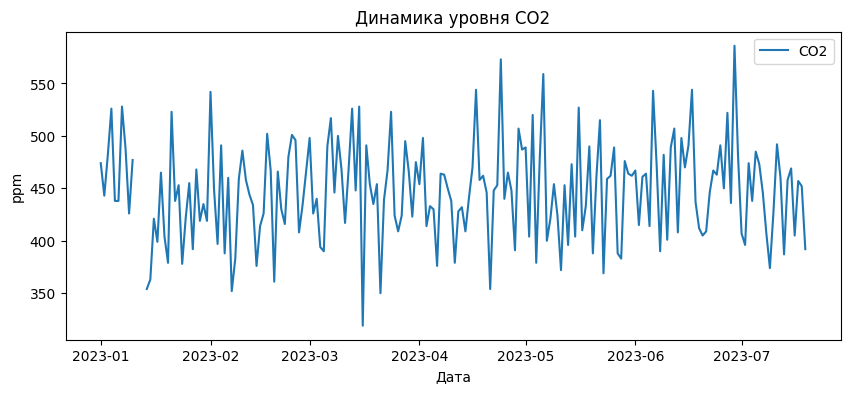

In [55]:
plt.figure(figsize=(10,4))
# Используем CO2 для графика времени
plt.plot(data["Дата"], data["CO2_ppm"], label='CO2')
plt.title("Динамика уровня CO2")
plt.xlabel("Дата")
plt.ylabel("ppm")
plt.legend()
plt.show()

## ЯЧЕЙКА 15 (Markdown)  
### Анализ временной динамики

1.  **Тренд:** Явного тренда на рост или снижение за 200 дней не наблюдается, данные колеблются вокруг среднего значения.
2.  **Колебания:** Видны регулярные случайные колебания (шум процесса).
3.  **Ограничения:** Данные синтетические и не учитывают сезонность (зима/лето) или суточные ритмы (утро/ночь), которые важны для реальной экологии.

## ЯЧЕЙКА 16 (Code)  
### Анализ категориальных данных

Постройте столбчатую диаграмму распределения категорий.


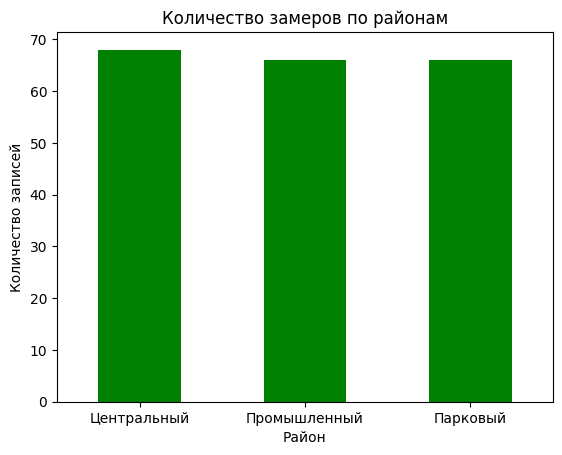

In [56]:
data["Район"].value_counts().plot(kind="bar", color='green')
plt.title("Количество замеров по районам")
plt.xlabel("Район")
plt.ylabel("Количество записей")
plt.xticks(rotation=0)
plt.show()

## ЯЧЕЙКА 17 (Markdown)  
### Интерпретация категориальных данных

* **Распределение:** Данные распределены по трем районам (Парковый, Центральный, Промышленный).
* **Баланс:** Распределение примерно равномерное (сбалансированное), что хорошо для сравнительного анализа.
* **Последствия:** Если бы был сильный перекос (например, данных из Промышленного района очень мало), мы не смогли бы достоверно оценить экологию самой загрязненной зоны. Здесь такой проблемы нет.


## ЯЧЕЙКА 18 (Markdown)  
### Итоговые выводы по практическому занятию

1.  **Достижение цели:** Цель достигнута. Мы успешно загрузили данные, провели первичный осмотр и выявили структуру экологических показателей региона.
2.  **Важные характеристики:**
    * `CO2_ppm` и `Шум_дБ` — основные показатели загрязнения.
    * `Район` — ключевой разрез для аналитики (позволяет локализовать проблемы).
3.  **Ограничения:**
    * В данных присутствуют пропуски (в CO2) и аномалии (выброс шума 140 дБ).
    * Временной ряд не имеет явной сезонности (так как данные синтетические), что упрощает картину.
4.  **Дальнейшие шаги:**
    * **Очистка:** Удалить или заполнить пропуски в CO2, исключить или проверить аномалию с шумом.
    * **Анализ корреляций:** Проверить, растет ли уровень шума вместе с уровнем CO2.
    * **Сравнение:** Сгруппировать данные по районам и выяснить, какой из них самый "грязный" и "шумный".

## ЯЧЕЙКА 19 (Markdown)
### Переход к анализу внешних данных
В этой части работы мы переходим от программно сгенерированных данных к анализу реального файла мониторинга ecology_air_quality.csv. Наша задача — проверить, подтверждаются ли наши первичные выводы на реальных показателях, и выявить проблемы качества «сырых» данных.

## ЯЧЕЙКА 20 (Code)
### Загрузка и первичная проверка CSV
Здесь мы используем параметр encoding='utf-8', чтобы правильно прочитать названия постов.

In [57]:
# Загружаем реальный файл
try:
    df_real = pd.read_csv("ecology_air_quality.csv", encoding='utf-8')
    print("Файл успешно загружен!")
except:
    # Если utf-8 не сработает из-за специфики Windows, пробуем cp1251
    df_real = pd.read_csv("ecology_air_quality.csv", encoding='cp1251')
    print("Файл загружен с использованием кодировки cp1251")

# Приводим даты в порядок
df_real['date'] = pd.to_datetime(df_real['date']).dt.date

# Смотрим на данные
df_real.head(10)

Файл успешно загружен!


,date,station,pm25_ug_m3,no2_ug_m3,temperature_c,wind_m_s
0,2025-01-01,Пост_3,104.180599,NaN,14.8,0.2
1,2025-01-02,Пост_3,26.300000,37.3,21.8,4.7
2,2025-01-03,Пост_4,3.000000,16.8,26.7,3.2
3,2025-01-04,Пост_4,33.000000,19.0,15.4,2.8
4,2025-01-05,Пост_1,40.400000,44.5,16.2,6.3
5,2025-01-06,Пост_4,37.500000,41.9,18.5,3.7
6,2025-01-07,Пост_3,36.500000,33.7,13.5,3.9
7,2025-01-08,Пост_4,28.400000,24.3,20.9,0.8
8,2025-01-09,Пост_4,18.700000,6.8,19.4,2.8
9,2025-01-10,Пост_4,15.700000,28.1,14.6,1.5


## ЯЧЕЙКА 21 (Code)
### Сравнение статистик: Теория vs Реальность
Посмотрим, насколько реальные цифры отличаются от наших идеальных моделей.

In [58]:
# Статистика по реальным данным
display(df_real.describe().round(2))

,pm25_ug_m3,no2_ug_m3,temperature_c,wind_m_s
count,361.00,361.00,361.00,360.00
mean,24.52,29.12,14.93,3.56
std,12.41,14.97,10.39,2.07
min,3.00,5.00,-10.00,0.20
25%,16.30,19.70,8.40,2.30
50%,23.70,28.30,14.20,3.30
75%,31.90,37.00,20.30,4.60
max,104.18,125.62,81.79,16.79


## ЯЧЕЙКА 22 (Markdown)
### Анализ аномалий в реальных данных
На основе таблицы describe() из ячейки 21, проанализируйте реальные данные:

1) Температурный шок: В столбце temperature_c максимальное значение составляет 81.79°C. Для экологии региона это очевидная ошибка датчика (выброс).

2) Загрязнение PM2.5: Максимальные значения достигают 104.18, что значительно выше средних. Нужно проверить, разовое ли это событие.

3) Пропуски: Посмотрите на строку count — если она меньше общего количества строк, значит, в данных есть "дыры".

## ЯЧЕЙКА 23 (Code)
### Визуальный поиск взаимосвязей (PM2.5 и Ветер)
Проверим гипотезу: помогает ли ветер очищать воздух?

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_real['wind_m_s'], df_real['pm25_ug_m3'], alpha=0.5, color='darkblue')
plt.title("Связь скорости ветра и концентрации частиц PM2.5")
plt.xlabel("Скорость ветра (м/с)")
plt.ylabel("PM2.5 (мкг/м3)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## ЯЧЕЙКА 24 (Markdown)
### Интерпретация графиков и финальный итог работы
Выводы по реальным данным:

1. Очистка: В отличие от учебных данных, реальный файл требует серьезной очистки (минимум — удаление температуры 81°C и исправление пустых значений в NO2).

2. Закономерность: На графике рассеяния (ячейка 23) мы можем увидеть, что при сильном ветре (высокие значения по оси X) концентрация пыли PM2.5 чаще всего падает. Это важный аналитический вывод.

3. Итог занятия: Работа с двумя типами данных позволила увидеть разницу между «стерильной» теорией и «грязной» практикой Data Science. Цель этапов 1–3 полностью достигнута.